In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image

In [ ]:
def CompararImagenes(Maximo,Minimo,Metrica):
    # Cargar FITS
    originalMax = fits.getdata(f"{Metrica}/{Maximo}.fits")
    mfbdMax = fits.getdata(f"{Metrica}/{Maximo}_MFBD.fits")

    originalMin = fits.getdata(f"{Metrica}/{Minimo}.fits")
    mfbdMin = fits.getdata(f"{Metrica}/{Minimo}_MFBD.fits")

    # Cargar PNG
    pngMax = np.array(Image.open(f"{Metrica}/{Maximo}.png"))
    pngMin = np.array(Image.open(f"{Metrica}/{Minimo}.png"))

    # Crear cuadrícula
    fig, axs = plt.subplots(2, 3, figsize=(9, 5))


    # Título general
    fig.suptitle(f'Comparación de imágenes - Métrica: {Metrica}',
                fontsize=16, fontweight='bold')

    # Etiquetas de las filas
    fig.text(0.02, 0.72, 'Máximo', rotation=90,
            va='center', fontsize=14)

    fig.text(0.02, 0.28, 'Mínimo', rotation=90,
            va='center', fontsize=14)

    # Originales
    axs[0][0].set_title("Original") 
    axs[0][0].imshow(originalMax[0], cmap='gray', origin='lower')
    axs[1][0].imshow(originalMin[0], cmap='gray', origin='lower')


    # Reconstruidas
    axs[0][1].set_title("Reconstrución") 
    axs[0][1].imshow(pngMax, cmap='gray', origin='lower')
    axs[1][1].imshow(pngMin, cmap='gray', origin='lower')

    # MFBD
    axs[0][2].set_title("MFBD") 
    axs[0][2].imshow(mfbdMax, cmap='gray', origin='lower')
    axs[1][2].imshow(mfbdMin , cmap='gray', origin='lower')
    axs[0,0].set_ylabel(f"Máximo\n{Maximo.rsplit("_", 1)[0]}", fontsize=12)
    axs[1,0].set_ylabel(f"Mínimo\n{Minimo.rsplit("_", 1)[0]}", fontsize=12)
    
    plt.tight_layout()
    plt.show()

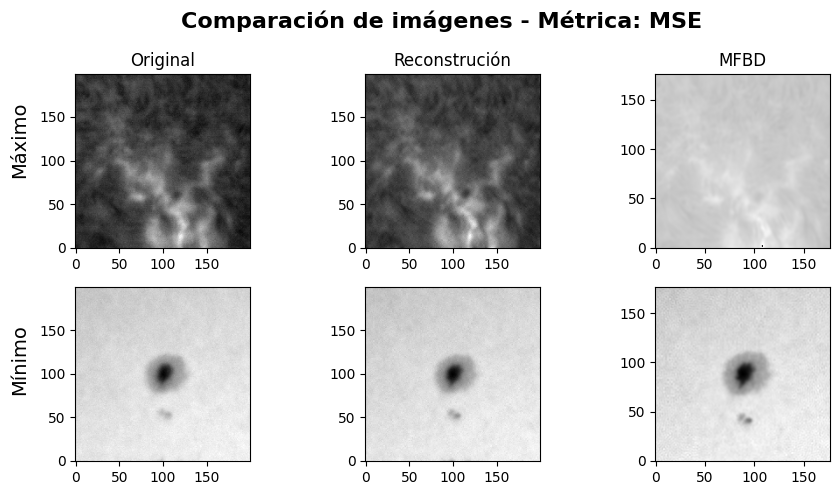

In [43]:
CompararImagenes("chromosphere_200p_00002","continuum_200p_00053","MSE")

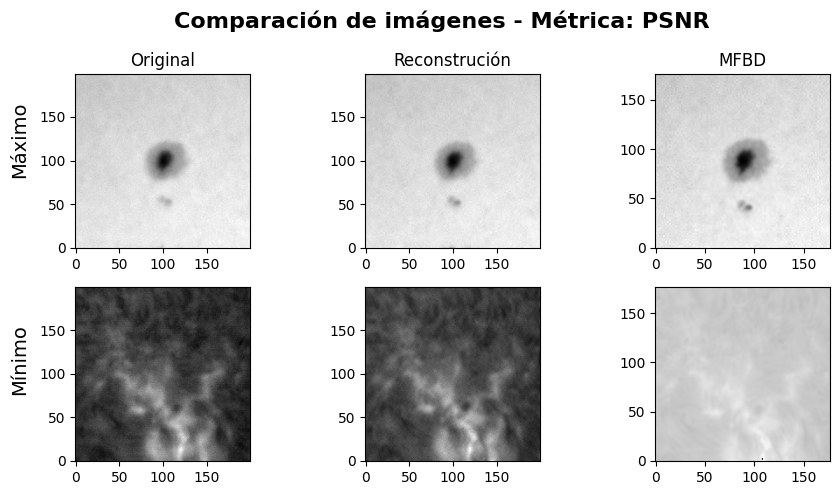

In [44]:
CompararImagenes("continuum_200p_00053","chromosphere_200p_00002","PSNR")

In [ ]:
CompararImagenes("continuum_200p_00053","chromosphere_200p_00002","SSIM")